# Face Detection with Haar Cascades

**Note: This is face *detection* NOT face *recognition*. We are only detecting if a face is in an image, not who the face actually is. That requires deep learning.**

**Name :** MITHUN S    **Reg. No :** 212224240088   **Slot No :** 26OD1199

## 1) Load and Display Images

- Step 1: Import necessary packages: numpy, cv2, matplotlib.pyplot
- Step 2: Load grayscale images using cv2.imread() with flag 0
- Step 3: Display images using plt.imshow() with cmap='gray'

In [55]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
from IPython.display import display, Image, clear_output
import time
import os
%matplotlib inline

## Images

In [34]:
with_glass = cv2.imread('image_02.png', 0)
with_out_glass = cv2.imread('image_01.png', 0)
group_photo = cv2.imread('image_03.png', 0)

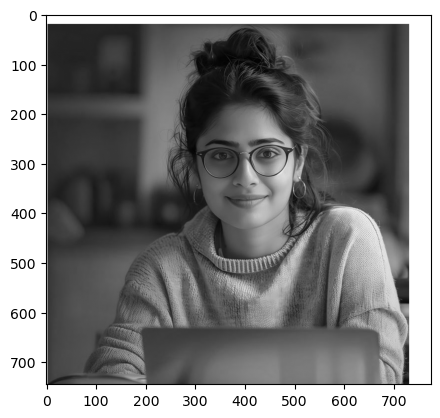

In [35]:
plt.imshow(with_glass,cmap='gray')
plt.show()

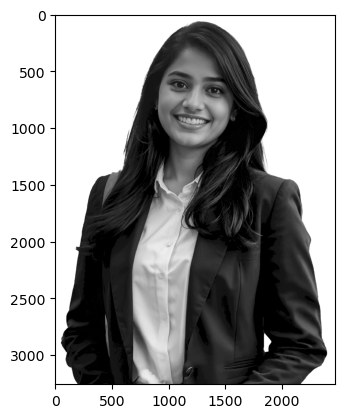

In [36]:
plt.imshow(with_out_glass,cmap='gray')
plt.show()

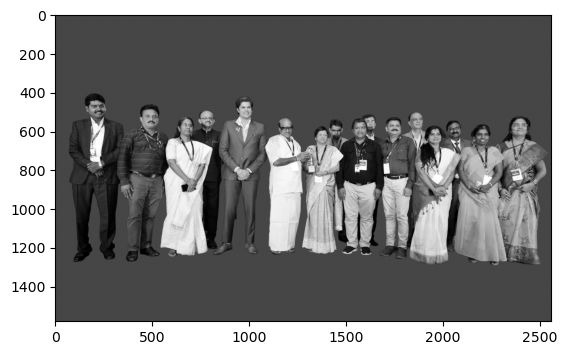

In [37]:
plt.imshow(group_photo,cmap='gray')
plt.show()

## II) Load Haar Cascade Classifiers

- Step 1: Load face and eye cascade XML files

## Face Detection

In [38]:
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

## III) Perform Face Detection in Images

- Step 1: Define a function detect_face() that copies the input image
- Step 2: Use face_cascade.detectMultiScale() to detect faces
- Step 3: Draw white rectangles around detected faces with thickness 10
- Step 4: Return the processed image with rectangles

In [39]:
def detect_face(img):
    
    face_img = img.copy()
    
    face_rects = face_cascade.detectMultiScale(face_img)
    
    for (x,y,w,h) in face_rects:
        cv2.rectangle(face_img, (x,y), (x+w,y+h), 255, 10)
        
    return face_img

In [40]:
result = detect_face(with_glass)

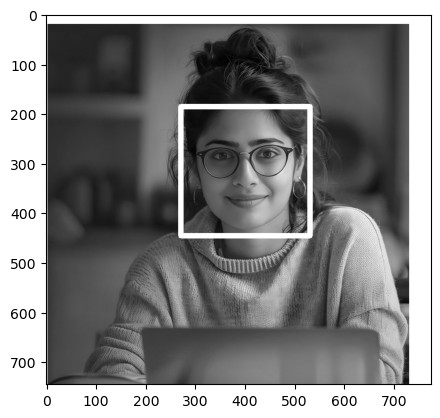

In [41]:
plt.imshow(result,cmap='gray')
plt.show()

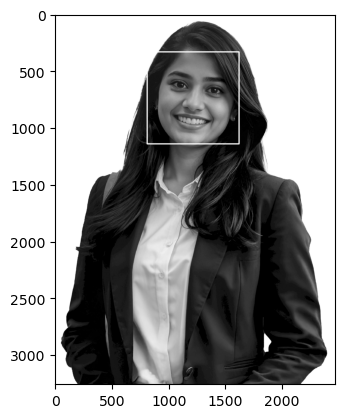

In [42]:
result = detect_face(with_out_glass)
plt.imshow(result,cmap='gray')
plt.show()

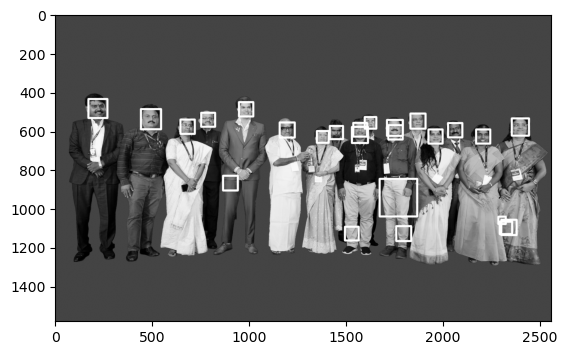

In [43]:
# Gets errors!
result = detect_face(group_photo)
plt.imshow(result,cmap='gray')
plt.show()

In [44]:
def adj_detect_face(img):
    
    face_img = img.copy()
    
    face_rects = face_cascade.detectMultiScale(face_img, 1.2, 5)
    
    for (x,y,w,h) in face_rects:
        cv2.rectangle(face_img, (x,y), (x+w,y+h), 255, 10)
        
    return face_img

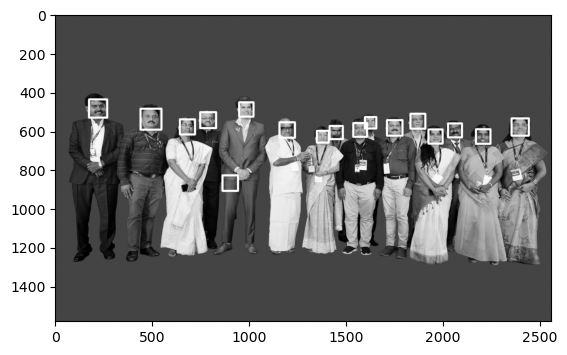

In [45]:
# Doesn't detect the side face.
result = adj_detect_face(group_photo)
plt.imshow(result,cmap='gray')
plt.show()

## IV) Perform Eye Detection in Images & Display Detection Results on Images

- Step 1: Define a function detect_eyes() that copies the input image
- Step 2: Use eye_cascade.detectMultiScale() to detect eyes
- Step 3: Draw white rectangles around detected eyes with thickness 10
- Step 4: Return the processed image with rectangles
- Step 5: Call detect_face() or detect_eyes() on loaded images
- Step 6: Use plt.imshow() with cmap='gray' to display images with detected regions highlighted

In [46]:
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')

In [47]:
def detect_eyes(img):
    
    face_img = img.copy()
    
    eyes = eye_cascade.detectMultiScale(face_img)
    
    for (x,y,w,h) in eyes:
        cv2.rectangle(face_img, (x,y), (x+w,y+h), 255, 10)
        
    return face_img

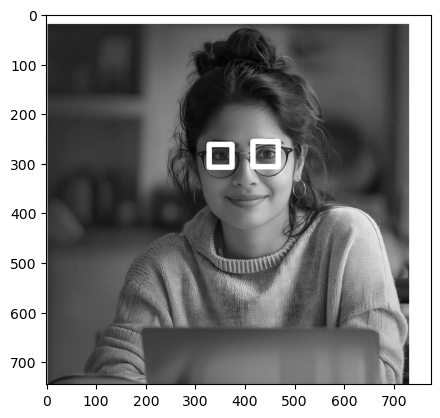

In [48]:
result = detect_eyes(with_glass)
plt.imshow(result,cmap='gray')
plt.show()

In [49]:
eyes = eye_cascade.detectMultiScale(with_out_glass) 

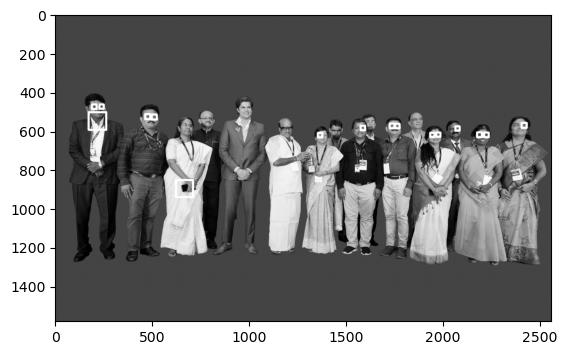

In [50]:
# White around the pupils is not distinct enough to detect eyes here!
result = detect_eyes(group_photo)
plt.imshow(result,cmap='gray')
plt.show()

## VI) Perform Face Detection on Real-Time Webcam Video

- Step 1: Capture video from webcam using cv2.VideoCapture(0)
- Step 2: Loop to continuously read frames from webcam
- Step 3: Apply detect_face() function on each frame
- Step 4: Display the video frame with rectangles around detected faces
- Step 5: Exit loop and close windows when ESC key (key code 27) is pressed
- Step 6: Release video capture and destroy all OpenCV windows

In [ ]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

In [54]:
import urllib.request

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml",
    "haarcascade_frontalface_default.xml"
)

print("Downloaded")

Downloaded


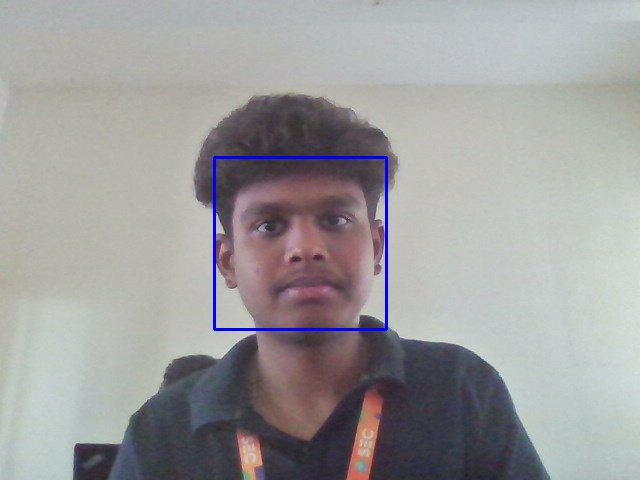

Webcam stopped


In [58]:
# Load Haar Cascade
cascade_path = "haarcascade_frontalface_default.xml"

face_cascade = cv2.CascadeClassifier(cascade_path)

# Check cascade
if face_cascade.empty():
    print("ERROR: Haar Cascade file not found!")
else:
    print("Haar Cascade loaded successfully")

    # Start webcam
    cap = cv2.VideoCapture(0)

    try:
        while True:
            ret, frame = cap.read()

            if not ret:
                print("Webcam not detected")
                break

            # Resize for faster processing
            frame = cv2.resize(frame, (640, 480))

            # Convert to grayscale
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            # Detect faces
            faces = face_cascade.detectMultiScale(
                gray,
                scaleFactor=1.2,
                minNeighbors=5,
                minSize=(40, 40)
            )

            # Draw rectangles
            for (x, y, w, h) in faces:
                cv2.rectangle(
                    frame,
                    (x, y),
                    (x + w, y + h),
                    (255, 0, 0),
                    2
                )

            # Display in Jupyter
            _, buffer = cv2.imencode(".jpg", frame)

            clear_output(wait=True)
            display(Image(data=buffer.tobytes()))

            time.sleep(0.05)

    except KeyboardInterrupt:
        print("Webcam stopped")

    finally:
        cap.release()
        cv2.destroyAllWindows()

In [59]:
cap.release()